In [1]:
import os
import csv
import torch
import torch.nn as nn

from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms
from PIL import Image


device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

Device: cuda


In [2]:
class SteeringDataset(Dataset):

    def __init__(self, csv_path, images_dir, transform=None):

        self.images_dir = images_dir
        self.transform = transform

        with open(csv_path, "r") as f:
            reader = csv.reader(f)
            self.samples = list(reader)[1:]

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):

        filename, steering = self.samples[idx]

        image_path = os.path.join(
            self.images_dir,
            filename
        )

        image = Image.open(
            image_path
        ).convert("RGB")

        if self.transform:
            image = self.transform(image)

        steering = torch.tensor(
            float(steering),
            dtype=torch.float32
        )

        return image, steering


transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])


images_dir = "datasets/clockwise/images"
csv_path = "datasets/clockwise/labels.csv"

dataset = SteeringDataset(
    csv_path,
    images_dir,
    transform
)

print("Total samples:", len(dataset))

Total samples: 3361


In [3]:
# ==========================================
# TRAIN / VALIDATION SPLIT
# ==========================================

train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

generator = torch.Generator().manual_seed(42)

train_dataset, val_dataset = random_split(
    dataset,
    [train_size, val_size],
    generator=generator
)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False
)

print("Train samples:", len(train_dataset))
print("Validation samples:", len(val_dataset))

Train samples: 2688
Validation samples: 673


In [4]:
class SteeringCNN(nn.Module):
    def __init__(self):
        super(SteeringCNN, self).__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=5, stride=2),
            nn.ReLU(),

            nn.Conv2d(16, 32, kernel_size=5, stride=2),
            nn.ReLU(),

            nn.Conv2d(32, 64, kernel_size=3, stride=2),
            nn.ReLU(),

            nn.AdaptiveAvgPool2d((4, 4))
        )

        self.regressor = nn.Sequential(
            nn.Flatten(),

            nn.Linear(64 * 4 * 4, 128),
            nn.ReLU(),

            nn.Dropout(0.2),

            nn.Linear(128, 1)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.regressor(x)
        return x.squeeze(1)


print("SteeringCNN ready!")

SteeringCNN ready!


Extreme left samples: 11


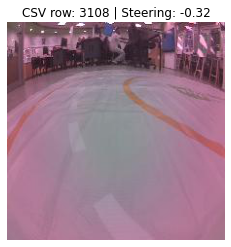

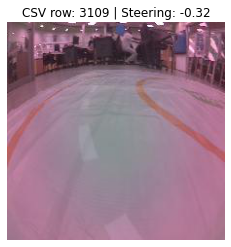

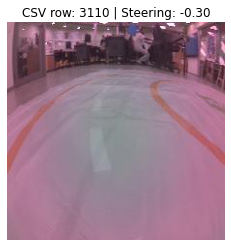

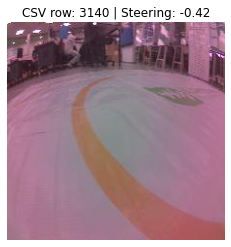

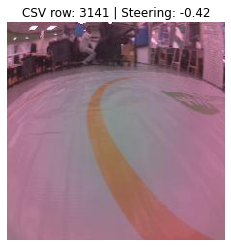

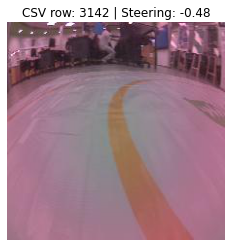

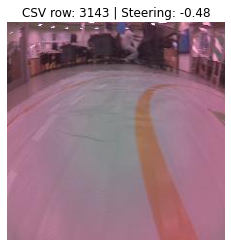

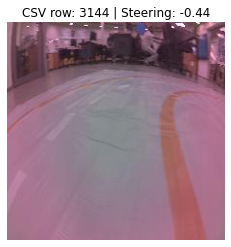

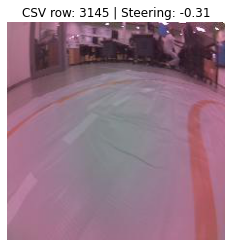

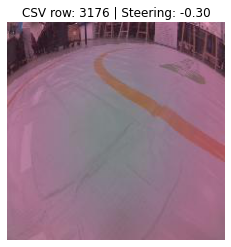

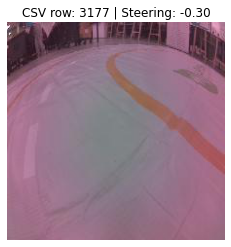

In [5]:
import csv
import os
import matplotlib.pyplot as plt
from PIL import Image

csv_path = "datasets/clockwise/labels.csv"
images_dir = "datasets/clockwise/images"

extreme_left = []

with open(csv_path, "r") as f:
    reader = csv.reader(f)
    next(reader)

    for row_number, row in enumerate(reader, start=2):
        filename = row[0]
        steering_value = float(row[1])

        if steering_value <= -0.30:
            extreme_left.append(
                (row_number, filename, steering_value)
            )

print("Extreme left samples:", len(extreme_left))

for row_number, filename, steering_value in extreme_left:

    image_path = os.path.join(images_dir, filename)
    image = Image.open(image_path).convert("RGB")

    plt.figure(figsize=(5, 4))
    plt.imshow(image)
    plt.axis("off")
    plt.title(
        f"CSV row: {row_number} | Steering: {steering_value:+.2f}"
    )
    plt.show()

In [6]:
finetune_model = SteeringCNN().to(device)

finetune_model.load_state_dict(
    torch.load(
        "models/clockwise_best_model_2868.pth",
        map_location=device
    )
)

finetune_model.train()

print("2868 best model loaded for fine-tuning!")

2868 best model loaded for fine-tuning!


In [ ]:
finetune_model = SteeringCNN().to(device)

finetune_model.load_state_dict(
    torch.load(
        "models/clockwise_best_model.pth",
        map_location=device
    )
)

finetune_model.train()

print("2378 best model loaded for fine-tuning!")

In [ ]:
finetune_model = SteeringCNN().to(device)

finetune_model.load_state_dict(
    torch.load(
        "models/clockwise_steering_1573_best.pth",
        map_location=device
    )
)

finetune_model.train()

print("1573 model loaded for fine-tuning!")

In [7]:
criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    finetune_model.parameters(),
    lr=0.0001
)

num_epochs = 20

print("Loss: MSELoss")
print("Optimizer: Adam")
print("Learning rate: 0.0001")
print("Maximum Epochs:", num_epochs)

Loss: MSELoss
Optimizer: Adam
Learning rate: 0.0001
Maximum Epochs: 20


In [8]:
# ==========================================
# FINE-TUNING + SAVE BEST MODEL
# ==========================================

best_val_loss = float("inf")
best_epoch = 0

save_path = "models/clockwise_best_model_3361.pth"

for epoch in range(num_epochs):

    # -----------------------------
    # TRAIN
    # -----------------------------
    finetune_model.train()

    train_loss_sum = 0.0

    for images, steerings in train_loader:

        images = images.to(device)
        steerings = steerings.to(device)

        optimizer.zero_grad()

        outputs = finetune_model(images)

        loss = criterion(outputs, steerings)

        loss.backward()
        optimizer.step()

        train_loss_sum += loss.item() * images.size(0)

    train_loss = train_loss_sum / len(train_dataset)


    # -----------------------------
    # VALIDATION
    # -----------------------------
    finetune_model.eval()

    val_loss_sum = 0.0

    with torch.no_grad():

        for images, steerings in val_loader:

            images = images.to(device)
            steerings = steerings.to(device)

            outputs = finetune_model(images)

            loss = criterion(outputs, steerings)

            val_loss_sum += loss.item() * images.size(0)

    val_loss = val_loss_sum / len(val_dataset)


    # -----------------------------
    # PRINT RESULTS
    # -----------------------------
    print(
        f"Epoch {epoch + 1}/{num_epochs} | "
        f"Train Loss: {train_loss:.6f} | "
        f"Val Loss: {val_loss:.6f}"
    )


    # -----------------------------
    # SAVE BEST
    # -----------------------------
    if val_loss < best_val_loss:

        best_val_loss = val_loss
        best_epoch = epoch + 1

        torch.save(
            finetune_model.state_dict(),
            save_path
        )

        print(
            f"   ✅ NEW BEST MODEL SAVED | "
            f"Val Loss: {best_val_loss:.6f}"
        )


print("\nTraining finished!")
print("Best Epoch:", best_epoch)
print("Best Validation Loss:", best_val_loss)
print("Saved model:", save_path)

Epoch 1/20 | Train Loss: 0.004170 | Val Loss: 0.003494
   ✅ NEW BEST MODEL SAVED | Val Loss: 0.003494
Epoch 2/20 | Train Loss: 0.003961 | Val Loss: 0.003357
   ✅ NEW BEST MODEL SAVED | Val Loss: 0.003357
Epoch 3/20 | Train Loss: 0.003906 | Val Loss: 0.003306
   ✅ NEW BEST MODEL SAVED | Val Loss: 0.003306
Epoch 4/20 | Train Loss: 0.003891 | Val Loss: 0.003382
Epoch 5/20 | Train Loss: 0.003819 | Val Loss: 0.003430
Epoch 6/20 | Train Loss: 0.003838 | Val Loss: 0.003396
Epoch 7/20 | Train Loss: 0.003603 | Val Loss: 0.003255
   ✅ NEW BEST MODEL SAVED | Val Loss: 0.003255
Epoch 8/20 | Train Loss: 0.003659 | Val Loss: 0.003295
Epoch 9/20 | Train Loss: 0.003553 | Val Loss: 0.004261
Epoch 10/20 | Train Loss: 0.003670 | Val Loss: 0.003266
Epoch 11/20 | Train Loss: 0.003555 | Val Loss: 0.003198
   ✅ NEW BEST MODEL SAVED | Val Loss: 0.003198
Epoch 12/20 | Train Loss: 0.003535 | Val Loss: 0.003169
   ✅ NEW BEST MODEL SAVED | Val Loss: 0.003169
Epoch 13/20 | Train Loss: 0.003519 | Val Loss: 0.003194

In [10]:
best_model = SteeringCNN().to(device)

best_model.load_state_dict(
    torch.load(
        "models/clockwise_best_model_3361.pth",
        map_location=device
    )
)

best_model.eval()

print("3361 model loaded!")

3361 model loaded!


In [ ]:
best_model = SteeringCNN().to(device)

best_model.load_state_dict(
    torch.load(
        "models/clockwise_best_model_2868.pth",
        map_location=device
    )
)

best_model.eval()

print("2868 model loaded!")

In [ ]:
best_model = SteeringCNN().to(device)

best_model.load_state_dict(
    torch.load(
        "models/clockwise_best_model.pth",
        map_location=device
    )
)

best_model.eval()

print("Best clockwise model loaded!")
print("Best Epoch: 48")
print("Best Val Loss: 0.00202145")

In [11]:
best_model.eval()

print("Strong right-turn predictions:")
print("--------------------------------")

count = 0

with torch.no_grad():

    for i in range(len(val_dataset)):

        image, actual = val_dataset[i]
        actual_value = actual.item()

        # רק פניות ימינה של 0.15 ומעלה
        if actual_value >= 0.15:

            prediction = best_model(
                image.unsqueeze(0).to(device)
            ).item()

            error = abs(actual_value - prediction)

            print(
                f"Actual: {actual_value:+.2f} | "
                f"Pred: {prediction:+.3f} | "
                f"Error: {error:.3f}"
            )

            count += 1

            if count >= 20:
                break

Strong right-turn predictions:
--------------------------------
Actual: +0.15 | Pred: +0.133 | Error: 0.017
Actual: +0.21 | Pred: +0.123 | Error: 0.087
Actual: +0.20 | Pred: +0.103 | Error: 0.097
Actual: +0.15 | Pred: +0.191 | Error: 0.041
Actual: +0.19 | Pred: +0.156 | Error: 0.034
Actual: +0.20 | Pred: +0.136 | Error: 0.064
Actual: +0.16 | Pred: +0.107 | Error: 0.053
Actual: +0.30 | Pred: +0.296 | Error: 0.004
Actual: +0.26 | Pred: +0.262 | Error: 0.002
Actual: +0.15 | Pred: +0.188 | Error: 0.038
Actual: +0.15 | Pred: +0.130 | Error: 0.020
Actual: +0.18 | Pred: +0.137 | Error: 0.043
Actual: +0.15 | Pred: +0.189 | Error: 0.039
Actual: +0.15 | Pred: +0.088 | Error: 0.062
Actual: +0.19 | Pred: +0.180 | Error: 0.010
Actual: +0.16 | Pred: -0.026 | Error: 0.186
Actual: +0.15 | Pred: +0.081 | Error: 0.069
Actual: +0.17 | Pred: +0.167 | Error: 0.003
Actual: +0.31 | Pred: +0.020 | Error: 0.290
Actual: +0.16 | Pred: +0.138 | Error: 0.022
